In [1]:
import os 
import glob 
from analysis.utils import *
from easydict import EasyDict
from data import load_dataset_1d
import torch 
from utils import LpLoss

In [2]:
weight1d_paths = glob.glob('./logs/exp1d/*/*/*100.pth')
weight1d_paths = [x for x in weight1d_paths if '512-512' in x]
log1d_paths = [x.replace('pth', 'csv') for x in weight1d_paths]

In [3]:
log1d_df = load_accuracy_log(log1d_paths)

100%|██████████| 99/99 [00:00<00:00, 577.95it/s]


In [4]:
log1d_df[log1d_df.dataset == 'cosine']

,model,dataset,coarse_level,resolution,residual,seed,test_l2,mcode
0,gt1d,cosine,4,512,ml1,100,0.130716,1
1,gt1d,cosine,4,512,ml4,100,0.050480,4
2,gt1d,cosine,4,512,ml2,100,0.079093,2
3,gt1d,cosine,4,512,ml3,100,0.049108,3
39,fno1d,cosine,4,512,diag,100,0.139690,0
40,fno1d,cosine,4,512,ml3,100,0.046697,3
41,fno1d,cosine,1,512,diag,100,0.032000,0
42,fno1d,cosine,3,512,ml2,100,0.037976,2
43,fno1d,cosine,4,512,ml4,100,0.039726,4
44,fno1d,cosine,3,512,ml1,100,0.052881,1


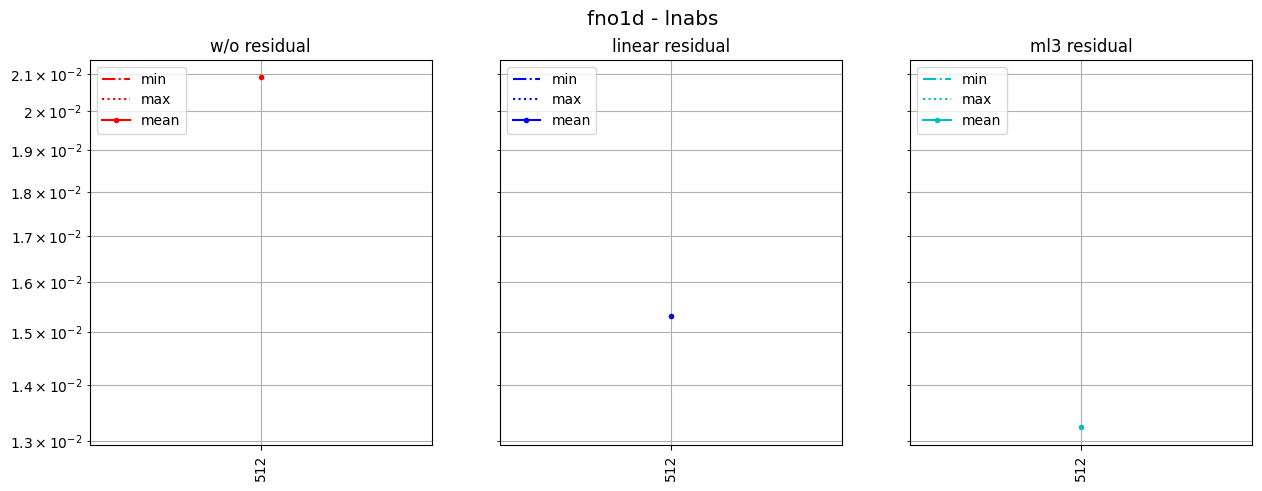

In [5]:
fig = vis1d_single_model_dataset_result(log1d_df, 'fno1d', 'lnabs', ml='ml3', clevel=0)

In [6]:
ds_cfg = EasyDict(
    {"ntrain":1000, 
     "ntest":200,
     "batch_size":1,
     "trasub":16,
     "dataset_nm":'cosine',
     "dataset_path":'/workdir/pde_data/'})

In [7]:
train_loader, test_loader, u_normalizer = load_dataset_1d(ds_cfg)

In [24]:
device = torch.device('cuda:1')
model_paths =  [x for x in weight1d_paths if ('cosine' in x) & ('mlx' in x)]
model = torch.load(model_paths[0]).to(device)

In [25]:
myloss = LpLoss(size_average=False)
u_normalizer.to(device)

In [26]:
with torch.no_grad():
    a, x, u = test_loader.dataset[4]
    a, x, u = a[None].to(device), x[None].to(device), u[None].to(device)
    bsz, seq_len = a.shape

    u_ = model(a=a, x=x).reshape(bsz, seq_len)
    u_ = u_normalizer.decode(u_)
    rl2 = myloss(u_.view(bsz, -1), u.view(bsz, -1)).item()

    a = a[0].cpu().numpy()
    x = x[0].cpu().numpy()
    u = u[0].cpu().numpy()
    u_ = u_[0].cpu().numpy()

print(rl2)

0.025149699300527573


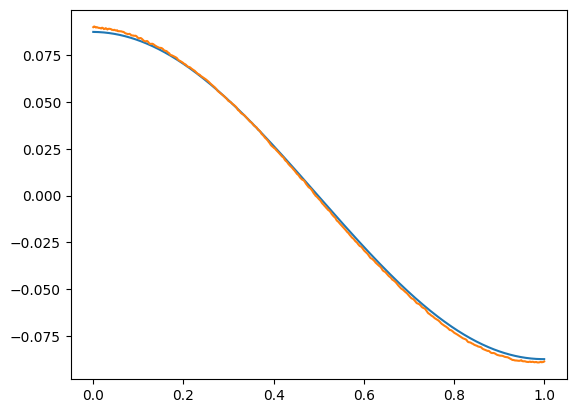

In [27]:
plt.plot(x, u, x, u_)